In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder ,OrdinalEncoder ,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix , ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

In [3]:
df_bank = pd.read_csv('/content/bankmarket.csv',sep=";")

In [4]:
features = ['age', 'duration', 'campaign', 'previous', 'housing', 'loan']
target = 'y'

X = df_bank[features].copy()
y = df_bank[target].copy()

In [5]:
y.head()

,y
0,no
1,no
2,no
3,no
4,no


In [6]:
binary_map = {'yes': 1, 'no': 0, 'unknown': 0}
X['housing'] = X['housing'].map(binary_map)
X['loan'] = X['loan'].map(binary_map)
y = y.map({'yes': 1, 'no': 0})

In [7]:
y.head()

,y
0,0
1,0
2,0
3,0
4,0


In [8]:
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
y = pd.to_numeric(y, errors='coerce').fillna(0).astype(int)

In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

In [10]:
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

numeric_features = ['age', 'duration', 'campaign', 'previous']
categorical_features = ['housing', 'loan']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

In [12]:
def evaluate_task1(model, name):
    val_acc = accuracy_score(y_val, model.predict(X_val))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"\n{name} Results:")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

In [13]:
from imblearn.pipeline import Pipeline

In [14]:
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(max_iter=1000))
])
pipeline_lr.fit(X_train, y_train)

pipeline_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('mlp', MLPClassifier(hidden_layer_sizes=(16, 8), activation='relu', max_iter=1000, random_state=42))
])
pipeline_mlp.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('mlp',
                 MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000,
                               random_state=42))])

In [15]:
evaluate_task1(pipeline_lr, "Pipeline Logistic Regression")
evaluate_task1(pipeline_mlp, "Pipeline MLP Classifier")


Pipeline Logistic Regression Results:
Validation Accuracy: 0.8132
Test Accuracy: 0.8094

Pipeline MLP Classifier Results:
Validation Accuracy: 0.7896
Test Accuracy: 0.7909


In [16]:
cols = ['parents', 'has_nurs', 'form', 'children', 'housing', 'finance', 'social', 'health', 'Class']

In [17]:
df_nursery = pd.read_csv('/content/nursery.csv',header=None, names=cols)

In [18]:
df_nursery['children'] = df_nursery['children'].replace({'1': '1', '2': '2', '3': '3', 'more': '3'})
X_nursery = df_nursery.drop('Class', axis=1)

In [19]:
X_train_nur, X_test_nur = train_test_split(X_nursery, test_size=0.30, random_state=42)

In [20]:
!pip install kmodes

In [21]:
import sys
!{sys.executable} -m pip install kmodes

In [22]:
from kmodes.kmodes import KModes
cost = []
K = range(1, 6)
for k in K:
    km = KModes(n_clusters=k, init='Huang', n_init=5, verbose=0)
    km.fit(X_train_nur)
    cost.append(km.cost_)

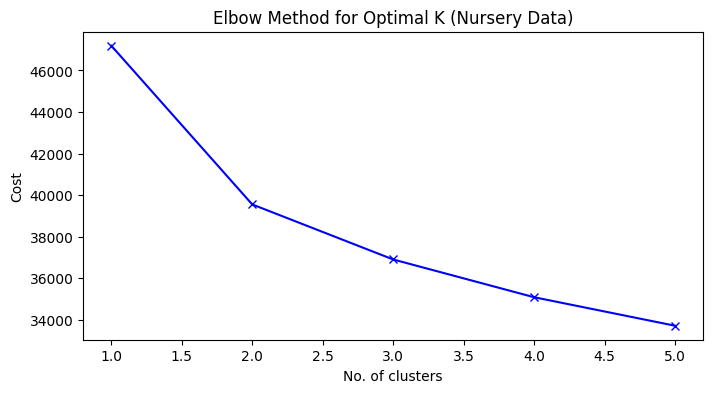

In [23]:
plt.figure(figsize=(8,4))
plt.plot(K, cost, 'bx-')
plt.xlabel('No. of clusters')
plt.ylabel('Cost')
plt.title('Elbow Method for Optimal K (Nursery Data)')
plt.show()

In [24]:
optimal_k = 3
km_model = KModes(n_clusters=optimal_k, init='Huang', n_init=5)
clusters_train = km_model.fit_predict(X_train_nur)
clusters_test = km_model.predict(X_test_nur)

In [25]:
print("\nCluster Centroids:")
print(pd.DataFrame(km_model.cluster_centroids_, columns=X_nursery.columns))


Cluster Centroids:
      parents   has_nurs        form children     housing     finance  \
0  great_pret  very_crit      foster        3   less_conv      inconv   
1       usual     proper  incomplete        3  convenient      inconv   
2  great_pret     proper      foster        2   less_conv  convenient   

          social       health  
0        nonprob     priority  
1  slightly_prob  recommended  
2    problematic    not_recom  


In [26]:
print("\nTrain Data Cluster Counts:")
print(pd.Series(clusters_train).value_counts())


Train Data Cluster Counts:
0    3945
1    3096
2    2031
Name: count, dtype: int64


In [27]:
print("\nTest Data Cluster Counts:")
print(pd.Series(clusters_test).value_counts())


Test Data Cluster Counts:
0    1707
1    1347
2     834
Name: count, dtype: int64


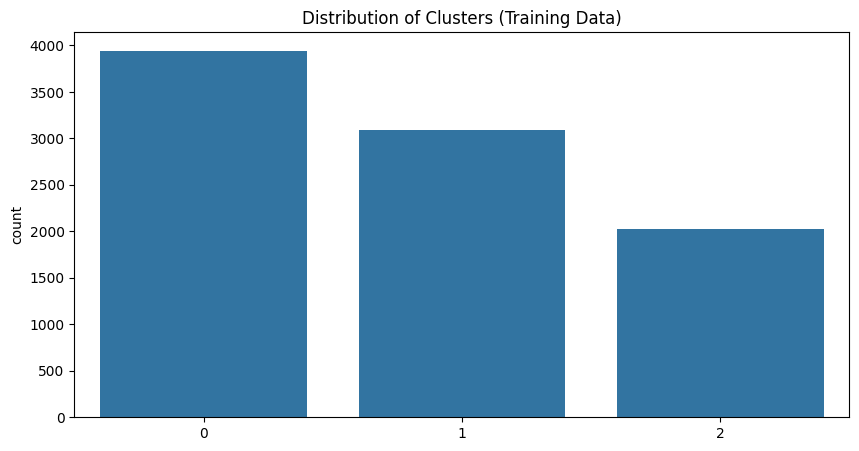

In [28]:
plt.figure(figsize=(10, 5))
sns.countplot(x=clusters_train)
plt.title("Distribution of Clusters (Training Data)")
plt.show()